# Example 12: Physics-Informed Neural Networks (PINN)

This example demonstrates how to train physics-informed RNNs for system
identification. Two approaches are shown:

1. **Basic RNN with collocation points** -- trained purely on physics
   constraints, with no measured data fitting at all. The model learns to
   satisfy the governing ODE on randomly generated excitation signals.
2. **PIRNN (Physics-Informed RNN)** -- combines data fitting with physics
   constraints and supports variable initial conditions via a StateEncoder.

Both approaches embed the system's governing equations directly into the
training loss, so the model is guided by physical laws rather than relying
solely on data.

## Prerequisites

- [Example 00: Your First Model](00_your_first_model.ipynb)
- [Example 01: Understanding the Data Pipeline](01_data_pipeline.ipynb)
- [Example 02: Simulation](02_simulation.ipynb)
- [Example 03: Prediction -- Using Output Feedback](03_prediction.ipynb)
- [Benchmark RNN](../../benchmarks/benchmark_rnn.py)

## Setup

In [1]:
from pathlib import Path

from tsfast.tsdata import create_dls
from tsfast.pinn import CollocationLoss, PhysicsLoss
from tsfast.pinn.differentiation import diff1_forward
from tsfast.pinn.signals import generate_excitation_signals
from tsfast.pinn.pirnn import PIRNNLearner
from tsfast.training import RNNLearner, fun_rmse, zero_loss

## The Spring-Damper System

We model a mass-spring-damper system governed by the second-order ODE:

```
m * a + c * v + k * x = u
```

where:

- **m** = mass
- **c** = damping coefficient
- **k** = spring constant
- **x** = position, **v** = velocity, **a** = acceleration
- **u** = external force (the input signal)

The system has **1 input** (force u) and **2 outputs** (position x,
velocity v). Our goal is to train a neural network that respects this
physical law.

## Physical Parameters and Physics Loss

The physics loss function encodes the governing ODE as a training
objective. It receives the model's input `u`, predictions `y_pred`, and
(optionally) reference data `y_ref`, and returns a dictionary of loss
components:

- **`physics`**: residual of the ODE -- should be zero if the model
  perfectly satisfies `ma + cv + kx = u`
- **`derivative`**: consistency between velocity v and the numerical
  derivative of position dx/dt
- **`initial`**: penalizes deviation from measured initial conditions
  (only when reference data `y_ref` is available)

In [2]:
MASS = 1.0
SPRING_CONSTANT = 1.0
DAMPING_COEFFICIENT = 0.1
DT = 0.01


def spring_damper_physics(u, y_pred, y_ref):
    """Physics loss for the spring-damper ODE: ma + cv + kx = u."""
    x, v = y_pred[:, :, 0], y_pred[:, :, 1]
    u_force = u[:, :, 0]

    a = diff1_forward(v, DT)
    dx_dt = diff1_forward(x, DT)

    loss = {
        'physics': ((MASS * a + DAMPING_COEFFICIENT * v + SPRING_CONSTANT * x - u_force) ** 2).mean(),
        'derivative': ((v - dx_dt) ** 2).mean(),
    }

    if y_ref is not None:
        init_sz = 10
        loss['initial'] = ((x[:, :init_sz] - y_ref[:, :init_sz, 0]) ** 2).mean()

    return loss

## Load the PINN Dataset

This example uses a locally bundled dataset in `test_data/pinn/`
(no download needed). The HDF5 files contain three datasets: `u` (force),
`x` (position), and `v` (velocity).

We use a robust path resolution that works whether the code runs as a
notebook (from `examples/notebooks/`) or as a script (from
`examples/scripts/`).

In [3]:
def _find_project_root(marker: str = "test_data") -> Path:
    """Walk up from script/notebook location to find the project root."""
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path(".").resolve()
    p = start
    while p != p.parent:
        if (p / marker).is_dir():
            return p
        p = p.parent
    raise FileNotFoundError(f"Could not find '{marker}' directory above {start}")


_root = _find_project_root()
path = _root / "test_data" / "pinn"

Key parameters:

- **`u=['u'], y=['x', 'v']`** -- column names matching the HDF5 dataset
  keys
- **`win_sz=100`** -- short windows because the PINN dataset has short
  trajectories (500 samples at 100 Hz = 5 seconds)
- **`stp_sz=1, valid_stp_sz=1`** -- step size of 1 gives maximum overlap
  between windows for more training data
- **`n_batches_train=300`** -- fixed number of training batches per epoch,
  important for PINN training where we want many gradient steps per epoch

In [4]:
dls = create_dls(
    u=['u'], y=['x', 'v'],
    dataset=path,
    win_sz=100, stp_sz=1, valid_stp_sz=1,
    bs=32, n_batches_train=300,
)

## Approach 1: Basic RNN with Collocation Points

This trains a standard RNN using **only** physics constraints -- no data
fitting at all. The model learns to satisfy the ODE on randomly generated
excitation signals (collocation points). This is useful as a physics
surrogate model: it can simulate the spring-damper system for any input
signal without ever having seen measured data.

Key design choices:

- **`zero_loss`** as the data loss: returns 0 for every batch. Physics is
  the **only** training signal. The model does not try to fit any specific
  trajectory.
- **`CollocationLoss`** generates random excitation signals each batch
  and computes the physics loss on the model's response to those signals.
- **`generate_excitation_signals`** creates random input signals (sines,
  steps, chirps, etc.). `amplitude_range` and `frequency_range` control
  the signal characteristics.
- Collocation points are generated in a background thread by default,
  overlapping generation with GPU compute.

In [5]:
learn = RNNLearner(
    dls, rnn_type='lstm', num_layers=1, hidden_size=10,
    loss_func=zero_loss, metrics=[fun_rmse],
)

learn.aux_losses.append(CollocationLoss(
    generate_pinn_input=lambda bs, sl, dev: generate_excitation_signals(
        bs, sl, n_inputs=1, dt=DT, device=dev,
        amplitude_range=(0.5, 2.0), frequency_range=(0.1, 3.0),
    ),
    physics_loss_func=spring_damper_physics,
    weight=1.0,
))

learn.fit_flat_cos(10, 3e-3)

Epoch 1/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/10:  45%|████▌     | 135/300 [00:00<00:00, 269.58it/s]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 269.58it/s, train=0.5173 | valid=0.0000 | fun_rmse=0.2276]

Epoch 1/10: 100%|██████████| 300/300 [00:00<00:00, 333.02it/s, train=0.5173 | valid=0.0000 | fun_rmse=0.2276]

Epoch 2/10:   0%|          | 0/300 [00:00<?, ?it/s]

...

Epoch 9/10: 100%|██████████| 300/300 [00:00<00:00, 402.64it/s, train=0.0081 | valid=0.0000 | fun_rmse=0.3234]

Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10:  72%|███████▏  | 215/300 [00:00<00:00, 428.16it/s]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 428.16it/s, train=0.0070 | valid=0.0000 | fun_rmse=0.3228]

Epoch 10/10: 100%|██████████| 300/300 [00:00<00:00, 426.71it/s, train=0.0070 | valid=0.0000 | fun_rmse=0.3228]

## Approach 1: Results

Since the model was trained purely on physics constraints, it has learned
to produce outputs that satisfy the ODE -- even though it never saw the
actual measured trajectories during training.

Two caveats when reading the numbers: the reported `valid` loss is just the
(zero) data loss `zero_loss` -- the physics losses are not evaluated during
validation -- so `valid=0.0000` does **not** mean a perfect fit; `fun_rmse`
is the real accuracy signal. And because collocation batches carry no
reference data (`y_ref=None`, so the `initial` term is skipped) while the
RNN always starts from a zero hidden state, the model satisfies the ODE but
cannot match the measured initial transient -- which caps its `fun_rmse`.
Approach 2 addresses exactly this with its `initial` anchor and the
StateEncoder.

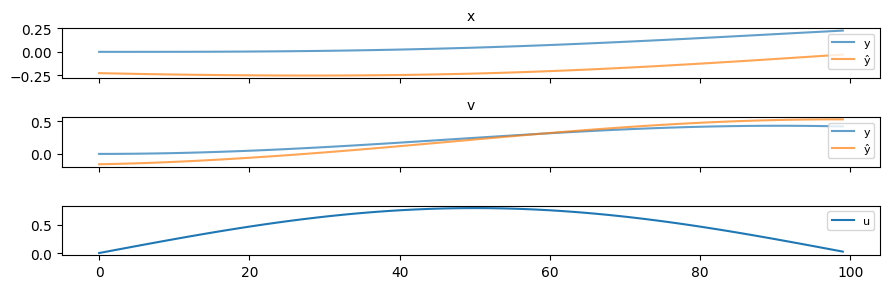

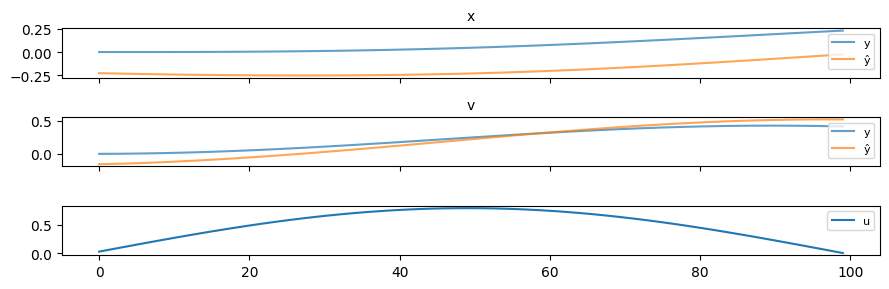

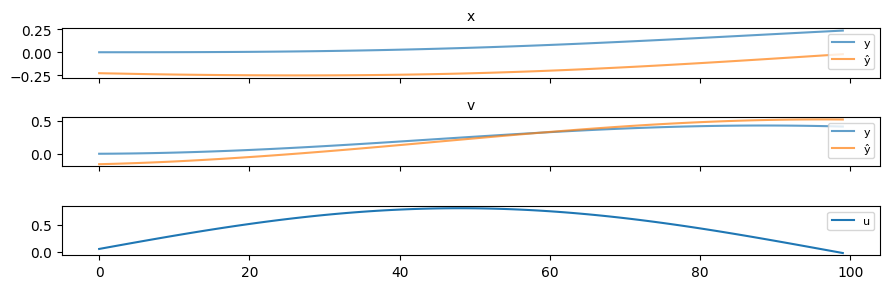

In [6]:
learn.show_results(max_n=3)

## Approach 2: PIRNN with Data + Physics

PIRNN (Physics-Informed RNN) combines data fitting with physics
constraints. It uses a dual-encoder architecture:

- A **SequenceEncoder** (diagnosis RNN) that processes an initialization
  window of measured data to estimate the system's hidden state
- A **StateEncoder** (MLP) that maps a single physical state vector
  directly to the RNN hidden state, enabling variable initial conditions
  at inference without needing a full initialization sequence

Two auxiliary losses enforce physics:

- **`PhysicsLoss`**: computes the physics loss on actual training
  data batches
- **`CollocationLoss`**: computes the physics loss on randomly
  generated input signals for better generalization

Key parameters:

- **`init_sz=10`** -- number of timesteps used for initialization
  (shorter than FranSys since we have a StateEncoder as backup)
- **`attach_output=True`** -- enables prediction mode, where the model
  receives past outputs as additional input
- **`state_encoder_hidden=32`** -- hidden dimension of the StateEncoder
  MLP
- **`loss_weights`** -- relative importance of each physics loss
  component. `initial` is weighted 10x higher to anchor predictions to
  measured initial conditions.
- **`init_mode='state_encoder'`** -- tells the collocation loss to
  initialize the model via the StateEncoder with random physical states
- **`output_ranges`** -- physical ranges for random state generation,
  one (min, max) tuple per output channel

In [7]:
learn = PIRNNLearner(
    dls, init_sz=10, attach_output=True,
    rnn_type='gru', rnn_layer=1, hidden_size=20,
    state_encoder_hidden=32,
    loss_func=zero_loss, metrics=[fun_rmse],
)

# Physics on training data
learn.aux_losses.append(PhysicsLoss(
    physics_loss_func=spring_damper_physics,
    weight=1.0,
    loss_weights={'physics': 1.0, 'derivative': 1.0, 'initial': 10.0},
    n_inputs=1,
))

# Physics on collocation points with StateEncoder initialization
learn.aux_losses.append(CollocationLoss(
    generate_pinn_input=lambda bs, sl, dev: generate_excitation_signals(
        bs, sl, n_inputs=1, dt=DT, device=dev,
        amplitude_range=(0.5, 2.0), frequency_range=(0.1, 3.0),
    ),
    physics_loss_func=spring_damper_physics,
    weight=0.5,
    init_mode='state_encoder',
    output_ranges=[(-1.0, 1.0), (-2.0, 2.0)],
))

learn.fit_flat_cos(10, 3e-3)

Epoch 1/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1/10:  35%|███▌      | 106/300 [00:00<00:00, 211.75it/s]

Epoch 1/10:  81%|████████  | 242/300 [00:01<00:00, 246.68it/s]

Epoch 1/10: 100%|██████████| 300/300 [00:01<00:00, 246.68it/s, train=3.6095 | valid=0.0000 | fun_rmse=0.2193]

Epoch 1/10: 100%|██████████| 300/300 [00:01<00:00, 246.03it/s, train=3.6095 | valid=0.0000 | fun_rmse=0.2193]

...

Epoch 10/10:   0%|          | 0/300 [00:00<?, ?it/s]

Epoch 10/10:  46%|████▌     | 138/300 [00:00<00:00, 275.13it/s]

Epoch 10/10:  92%|█████████▏| 277/300 [00:01<00:00, 275.89it/s]

Epoch 10/10: 100%|██████████| 300/300 [00:01<00:00, 275.89it/s, train=3.0679 | valid=0.0000 | fun_rmse=0.2262]

Epoch 10/10: 100%|██████████| 300/300 [00:01<00:00, 272.49it/s, train=3.0679 | valid=0.0000 | fun_rmse=0.2262]

## Approach 2: Results

The PIRNN model benefits from both data fitting and physics constraints.
The StateEncoder allows it to handle variable initial conditions. As in
Approach 1, `valid` shows only the zero data loss -- judge accuracy by
`fun_rmse`.

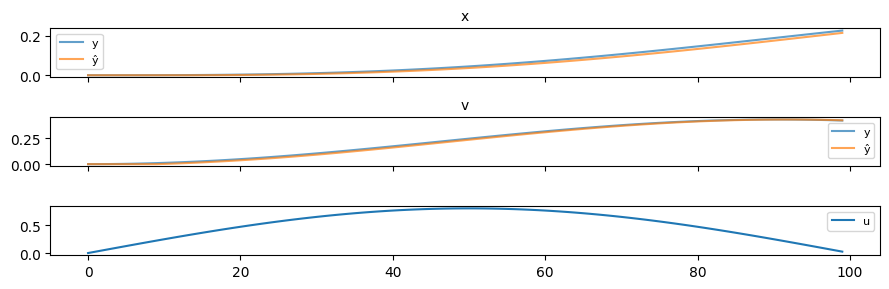

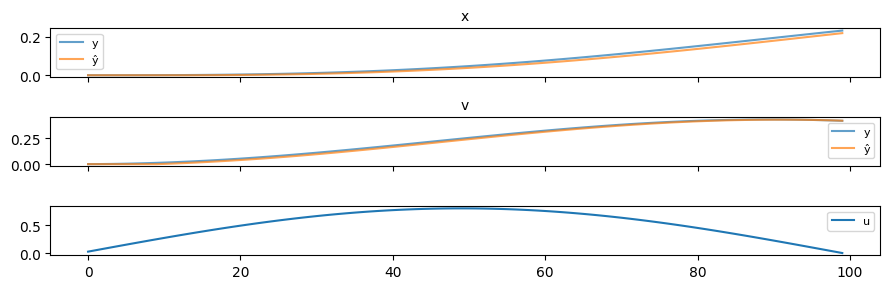

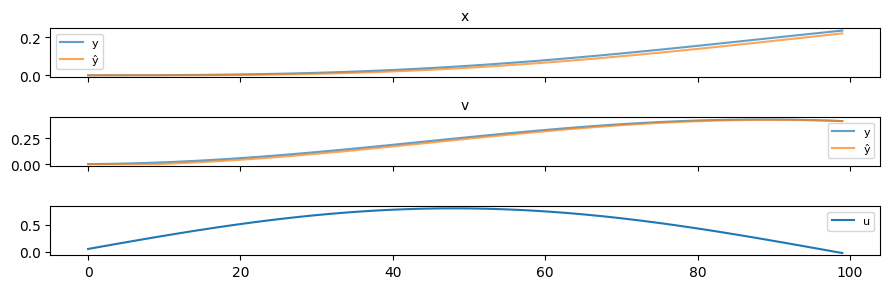

In [8]:
learn.show_results(max_n=3)

## Key Takeaways

- **PINNs embed physical laws directly into the training process** via
  custom loss functions that penalize ODE residuals.
- **Approach 1 (collocation only)** creates a physics surrogate model
  with no measured data -- useful when the governing equations are known
  but data is unavailable.
- **Approach 2 (PIRNN)** combines data fitting with physics constraints
  for better accuracy and generalization.
- **`zero_loss`** is used when physics is the only training signal -- it
  returns 0 so the physics auxiliary losses provide 100% of the gradient.
- **`PhysicsLoss`** enforces physics on real training data;
  **`CollocationLoss`** enforces physics on randomly generated
  excitation signals for broader coverage.
- **`StateEncoder`** maps a physical state vector to an RNN hidden state,
  enabling variable initial conditions without a full initialization
  sequence.
- PINNs are especially useful when **data is scarce but the governing
  equations are known**.